# Deep Learning Models for Early Sepsis Prediction
## GRU-based Temporal Modelling on ICU Time-Series Data

### Objectives of this notebook
- Convert processed row-level ICU data into fixed-length temporal sequences
- Train a GRU model to predict sepsis using the previous 24 hours of history
- Evaluate performance using AUROC and AUPRC
- Compare deep learning performance against baseline machine learning models

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, average_precision_score

Device setup + reproducibility

In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Load processed datasets

In [5]:
PROCESSED_DIR = Path("../data/processed")

train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")
test  = pd.read_parquet(PROCESSED_DIR / "test.parquet")

feature_cols = pd.read_csv(PROCESSED_DIR / "feature_cols.csv")["feature"].tolist()
target_col = "SepsisLabel"

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)
print("Number of features:", len(feature_cols))

Train shape: (1086436, 81)
Val shape: (231472, 81)
Test shape: (234302, 81)
Number of features: 78


In [6]:
print(train.columns[:10].tolist())
print("Patient_ID in train?", "Patient_ID" in train.columns)
print("ICULOS in train?", "ICULOS" in train.columns)

['Patient_ID', 'ICULOS', 'SepsisLabel', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
Patient_ID in train? True
ICULOS in train? True


Sequence Length

In [7]:
SEQUENCE_LENGTH = 24

print("Sequence length:", SEQUENCE_LENGTH)

Sequence length: 24


Sort data by patient and time

In [8]:
train = train.sort_values(["Patient_ID", "ICULOS"]).reset_index(drop=True)
val   = val.sort_values(["Patient_ID", "ICULOS"]).reset_index(drop=True)
test  = test.sort_values(["Patient_ID", "ICULOS"]).reset_index(drop=True)

print("Datasets sorted by Patient_ID and ICULOS.")

Datasets sorted by Patient_ID and ICULOS.


### Sequence Creation Strategy

For each patient and each ICU hour, the model will use up to the previous 24 hours of feature history to predict the sepsis label at the current hour.

- No future information is used
- Shorter histories at the start of an ICU stay will be left-padded with zeros
- This ensures a fixed input shape for the GRU model

In [9]:
def build_sequences(df, feature_cols, target_col, seq_len=24):
    sequences = []
    labels = []

    for patient_id, group in df.groupby("Patient_ID"):
        group = group.sort_values("ICULOS")
        x = group[feature_cols].values.astype(np.float32)
        y = group[target_col].values.astype(np.float32)

        for i in range(len(group)):
            start_idx = max(0, i - seq_len + 1)
            seq = x[start_idx:i+1]

            # Left-pad with zeros if sequence is shorter than seq_len
            if len(seq) < seq_len:
                pad_width = seq_len - len(seq)
                pad = np.zeros((pad_width, x.shape[1]), dtype=np.float32)
                seq = np.vstack([pad, seq])

            sequences.append(seq)
            labels.append(y[i])

    return np.array(sequences), np.array(labels)

Build sequence indices only

In [12]:
def build_sequence_index(df, patient_id_col="Patient_ID"):
    """
    For each row, store:
    - its own row index (prediction time)
    - the starting row index of that patient's ICU stay

    This allows us to reconstruct the previous 24 hours on the fly.
    """
    patient_ids = df[patient_id_col].to_numpy()

    # Mark where each patient begins
    patient_start_flags = np.r_[True, patient_ids[1:] != patient_ids[:-1]]
    patient_starts = np.where(patient_start_flags)[0]

    # For every row, record the start row of that patient's stay
    row_patient_start = np.empty(len(df), dtype=np.int32)
    for start, end in zip(patient_starts, np.r_[patient_starts[1:], len(df)]):
        row_patient_start[start:end] = start

    row_indices = np.arange(len(df), dtype=np.int32)

    return row_indices, row_patient_start

Create indices for train/val/test

In [13]:
train_row_idx, train_patient_start = build_sequence_index(train, patient_id_col="Patient_ID")
val_row_idx, val_patient_start     = build_sequence_index(val, patient_id_col="Patient_ID")
test_row_idx, test_patient_start   = build_sequence_index(test, patient_id_col="Patient_ID")

print("Train sequence count:", len(train_row_idx))
print("Validation sequence count:", len(val_row_idx))
print("Test sequence count:", len(test_row_idx))

Train sequence count: 1086436
Validation sequence count: 231472
Test sequence count: 234302


Visualization: effective history length

In [14]:
train_history_len = np.minimum(SEQUENCE_LENGTH, train_row_idx - train_patient_start + 1)

print("Train history length summary:")
print(pd.Series(train_history_len).describe())

Train history length summary:
count    1.086436e+06
mean     1.698212e+01
std      7.875223e+00
min      1.000000e+00
25%      1.000000e+01
50%      2.000000e+01
75%      2.400000e+01
max      2.400000e+01
dtype: float64


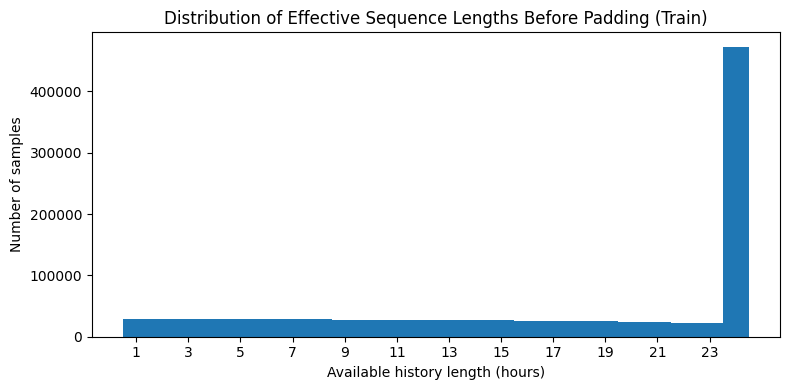

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(train_history_len, bins=np.arange(1, SEQUENCE_LENGTH + 2) - 0.5)

plt.title("Distribution of Effective Sequence Lengths Before Padding (Train)")
plt.xlabel("Available history length (hours)")
plt.ylabel("Number of samples")
plt.xticks(range(1, SEQUENCE_LENGTH + 1, 2))
plt.tight_layout()
plt.show()

PyTorch Dataset that builds sequences on demand

In [16]:
class SepsisSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, row_idx, patient_start_idx, seq_len=24):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.row_idx = row_idx
        self.patient_start_idx = patient_start_idx
        self.seq_len = seq_len

        self.X = self.df[feature_cols].to_numpy(dtype=np.float32)
        self.y = self.df[target_col].to_numpy(dtype=np.float32)

    def __len__(self):
        return len(self.row_idx)

    def __getitem__(self, idx):
        end = self.row_idx[idx]
        patient_start = self.patient_start_idx[idx]

        start = max(patient_start, end - self.seq_len + 1)
        seq = self.X[start:end + 1]

        # Left-pad with zeros if sequence is shorter than seq_len
        if len(seq) < self.seq_len:
            pad_len = self.seq_len - len(seq)
            pad = np.zeros((pad_len, self.X.shape[1]), dtype=np.float32)
            seq = np.vstack([pad, seq])

        label = self.y[end]

        return torch.tensor(seq, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)

Create Datasets

In [17]:
train_dataset = SepsisSequenceDataset(
    train, feature_cols, target_col,
    train_row_idx, train_patient_start,
    seq_len=SEQUENCE_LENGTH
)

val_dataset = SepsisSequenceDataset(
    val, feature_cols, target_col,
    val_row_idx, val_patient_start,
    seq_len=SEQUENCE_LENGTH
)

test_dataset = SepsisSequenceDataset(
    test, feature_cols, target_col,
    test_row_idx, test_patient_start,
    seq_len=SEQUENCE_LENGTH
)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:  ", len(val_dataset))
print("Test dataset size: ", len(test_dataset))

Train dataset size: 1086436
Val dataset size:   231472
Test dataset size:  234302


In [18]:
sample_x, sample_y = train_dataset[0]

print("Sequence shape:", sample_x.shape)
print("Label:", sample_y.item())

Sequence shape: torch.Size([24, 78])
Label: 0.0


Create DataLoaders

In [19]:
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created.")

DataLoaders created.


Compute positive class weight

In [20]:
# Compute positive class weight from training labels
num_pos = (train[target_col] == 1).sum()
num_neg = (train[target_col] == 0).sum()

pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float32).to(device)

print("Training positives:", int(num_pos))
print("Training negatives:", int(num_neg))
print("Positive class weight:", round((num_neg / num_pos), 2))

Training positives: 19560
Training negatives: 1066876
Positive class weight: 54.54


Define GRU Model

In [21]:
class GRUSepsisModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        output, hidden = self.gru(x)

        # Use the final hidden state
        last_hidden = hidden[-1]   # shape: (batch_size, hidden_dim)

        out = self.dropout(last_hidden)
        logits = self.fc(out).squeeze(1)

        return logits

Initialize model, loss, optimizer

In [22]:
input_dim = len(feature_cols)

model = GRUSepsisModel(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=1,
    dropout=0.2
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

GRUSepsisModel(
  (gru): GRU(78, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Training Function

In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

Evaluation Function

In [24]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * X_batch.size(0)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    auroc = roc_auc_score(all_labels, all_probs)
    auprc = average_precision_score(all_labels, all_probs)

    return avg_loss, auroc, auprc

Train the GRU

In [25]:
EPOCHS = 5

train_losses = []
val_losses = []
val_aurocs = []
val_auprcs = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auroc, val_auprc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aurocs.append(val_auroc)
    val_auprcs.append(val_auprc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val AUROC: {val_auroc:.4f} | "
          f"Val AUPRC: {val_auprc:.4f}")

Epoch 1/5 | Train Loss: 1.3265 | Val Loss: 1.3413 | Val AUROC: 0.5852 | Val AUPRC: 0.0275
Epoch 2/5 | Train Loss: 1.3240 | Val Loss: 1.3464 | Val AUROC: 0.5734 | Val AUPRC: 0.0228
Epoch 3/5 | Train Loss: 1.3319 | Val Loss: 1.3455 | Val AUROC: 0.5806 | Val AUPRC: 0.0244
Epoch 4/5 | Train Loss: 1.3312 | Val Loss: 1.3417 | Val AUROC: 0.5826 | Val AUPRC: 0.0235
Epoch 5/5 | Train Loss: 1.3299 | Val Loss: 1.3389 | Val AUROC: 0.5844 | Val AUPRC: 0.0245


Visualization: Training and validation loss curves

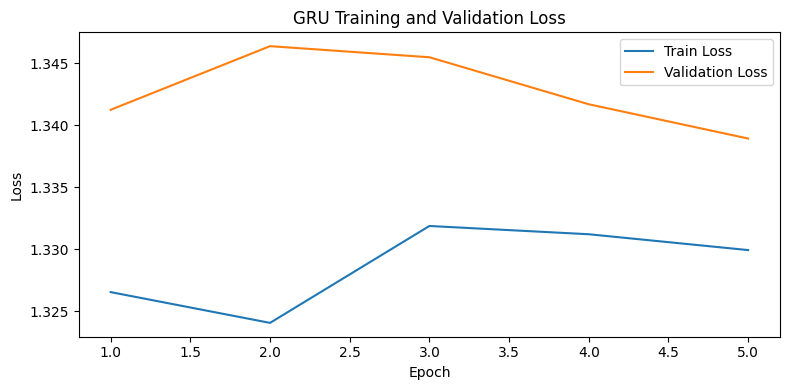

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

Visualization: Validation AUROC and AUPRC over epochs

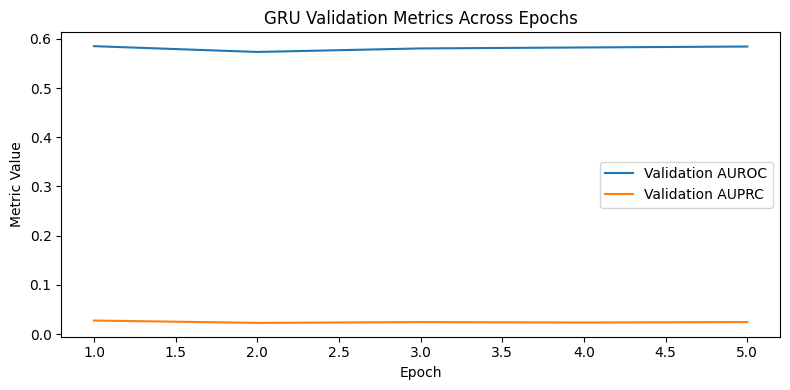

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), val_aurocs, label="Validation AUROC")
plt.plot(range(1, EPOCHS + 1), val_auprcs, label="Validation AUPRC")

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("GRU Validation Metrics Across Epochs")
plt.legend()
plt.tight_layout()
plt.show()

Test Evaluations

In [28]:
test_loss, test_auroc, test_auprc = evaluate(model, test_loader, criterion, device)

print("GRU Test Results")
print("Test Loss:", round(test_loss,4))
print("Test AUROC:", round(test_auroc,4))
print("Test AUPRC:", round(test_auprc,4))

GRU Test Results
Test Loss: 1.3184
Test AUROC: 0.6157
Test AUPRC: 0.0259


Model Comparison

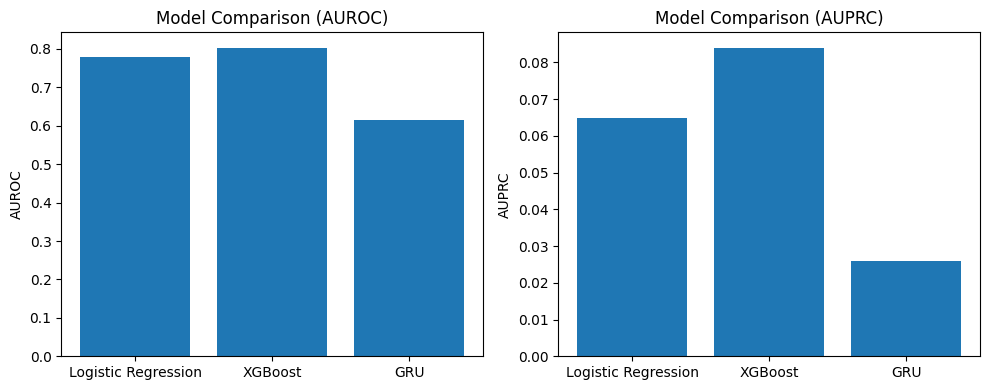

In [29]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "XGBoost", "GRU"]

auroc_scores = [0.778, 0.803, test_auroc]
auprc_scores = [0.065, 0.084, test_auprc]

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].bar(models, auroc_scores)
ax[0].set_title("Model Comparison (AUROC)")
ax[0].set_ylabel("AUROC")

ax[1].bar(models, auprc_scores)
ax[1].set_title("Model Comparison (AUPRC)")
ax[1].set_ylabel("AUPRC")

plt.tight_layout()
plt.show()

In [35]:
results_final = pd.DataFrame([
    {"Model": "Logistic Regression", "Test AUROC": 0.7784, "Test AUPRC": 0.0655},
    {"Model": "XGBoost", "Test AUROC": 0.8035, "Test AUPRC": 0.0845},
    {"Model": "GRU", "Test AUROC": 0.6157, "Test AUPRC": 0.0259},
])

results_final

,Model,Test AUROC,Test AUPRC
0,Logistic Regression,0.7784,0.0655
1,XGBoost,0.8035,0.0845
2,GRU,0.6157,0.0259
